In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import os
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam



In [2]:
dataset_path = r"C:\Users\TravelMate\Desktop\python\coraldataset"


In [3]:
def convert_path_to_df(dataset):
    image_dir = Path(dataset)

    filepaths = list(image_dir.glob('**/*.jpg')) + \
                list(image_dir.glob('**/*.png')) + \
                list(image_dir.glob('**/*.jpeg'))

    labels = [x.parent.name for x in filepaths]

    filepaths = [str(x) for x in filepaths]

    df = pd.DataFrame({
        'Filepath': filepaths,
        'Label': labels
    })

    return df
image_df = convert_path_to_df(dataset_path)
print(image_df.head())
print(type(image_df['Filepath'][0]))   


                                            Filepath     Label
0  C:\Users\TravelMate\Desktop\python\coraldatase...  Bleached
1  C:\Users\TravelMate\Desktop\python\coraldatase...  Bleached
2  C:\Users\TravelMate\Desktop\python\coraldatase...  Bleached
3  C:\Users\TravelMate\Desktop\python\coraldatase...  Bleached
4  C:\Users\TravelMate\Desktop\python\coraldatase...  Bleached
<class 'str'>


In [4]:
train_val_df, test_df = train_test_split(
    image_df,
    test_size=0.10,
    stratify=image_df['Label'],
    random_state=42
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.333,
    stratify=train_val_df['Label'],
    random_state=42
)
print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 949
Validation: 474
Test: 159


In [5]:
from tensorflow.keras.applications.densenet import preprocess_input

train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_images = train_gen.flow_from_dataframe(
    train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    class_mode='categorical',
    subset='training'
)

val_images = train_gen.flow_from_dataframe(
    train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    class_mode='categorical',
    subset='validation'
)

test_images = test_gen.flow_from_dataframe(
    test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224,224),
    class_mode='categorical',
    shuffle=False
)


Found 760 validated image filenames belonging to 3 classes.
Found 189 validated image filenames belonging to 3 classes.
Found 159 validated image filenames belonging to 3 classes.


In [6]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)

outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=Adam(0.00005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d                │ (None, 230, 230, 3)       │               0 │ input_layer[0][0]          │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,408 │ zero_padding2d[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ zero_padding2d_1              │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
│ (ZeroPadding2D)               │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1 (MaxPooling2D)          │ (None, 56, 56, 64)        │               0 │ zero_padding2d_1[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_bn             │ (None, 56, 56, 64)        │             256 │ pool1[0][0]                │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_0_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 128)       │           8,192 │ conv2_block1_0_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 128)       │             512 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 128)       │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 32)        │          36,864 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_concat           │ (None, 56, 56, 96)        │               0 │ pool1[0][0],               │
│ (Concatenate)                 │                           │               

 Total params: 7,301,699 (27.85 MB)

 Trainable params: 7,217,539 (27.53 MB)

 Non-trainable params: 84,160 (328.75 KB)

In [7]:
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=30
)

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 675s 22s/step - accuracy: 0.5382 - loss: 1.2373 - val_accuracy: 0.4709 - val_loss: 0.9732
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 512s 21s/step - accuracy: 0.7329 - loss: 0.7144 - val_accuracy: 0.7407 - val_loss: 0.6572
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 515s 21s/step - accuracy: 0.8158 - loss: 0.4794 - val_accuracy: 0.7937 - val_loss: 0.4865
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 539s 23s/step - accuracy: 0.8868 - loss: 0.3076 - val_accuracy: 0.8519 - val_loss: 0.4259
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 551s 23s/step - accuracy: 0.8921 - loss: 0.2963 - val_accuracy: 0.8889 - val_loss: 0.3124
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 512s 21s/step - accuracy: 0.9105 - loss: 0.2351 - val_accuracy: 0.8995 - val_loss: 0.2751
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 22072s 959s/step - accuracy: 0.9145 - loss: 0.2480 - val_accuracy: 0.9153 - val_loss: 0.2581
Epoch 8/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 472s 19s/step - accuracy: 0.9289 - loss: 0.1792 - val_accuracy:

In [8]:
loss, acc = model.evaluate(test_images)
print("DenseNet Test Accuracy:", acc*100)


5/5 ━━━━━━━━━━━━━━━━━━━━ 21s 4s/step - accuracy: 0.9623 - loss: 0.1260
DenseNet Test Accuracy: 96.22641801834106


In [10]:
model.save("coral_densenet121.h5")
print("Model saved!")


Model saved!


In [11]:
import numpy as np

predictions = model.predict(test_images)

y_pred = np.argmax(predictions, axis=1)

y_true = np.array(test_images.classes)

class_names = list(test_images.class_indices.keys())

print("Classes:", class_names)
print("Pred shape:", y_pred.shape)
print("True shape:", y_true.shape)

5/5 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step
Classes: ['Bleached', 'Dead', 'Healthy']
Pred shape: (159,)
True shape: (159,)


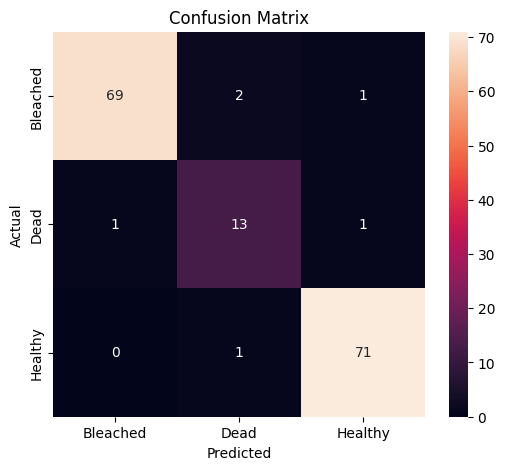

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9634360115201419
Recall: 0.9622641509433962
F1 Score: 0.9626592514137864


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    Bleached       0.99      0.96      0.97        72
        Dead       0.81      0.87      0.84        15
     Healthy       0.97      0.99      0.98        72

    accuracy                           0.96       159
   macro avg       0.92      0.94      0.93       159
weighted avg       0.96      0.96      0.96       159



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step


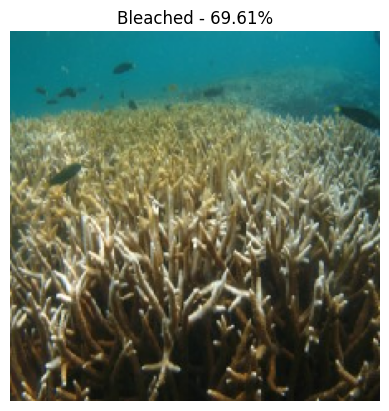

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0]

    class_names = list(train_images.class_indices.keys())
    predicted_class = class_names[np.argmax(pred)]
    confidence = np.max(pred) * 100

    plt.imshow(img)
    plt.title(f"{predicted_class} - {confidence:.2f}%")
    plt.axis('off')
    plt.show()

predict_image(r"C:\Users\TravelMate\Desktop\test2.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step


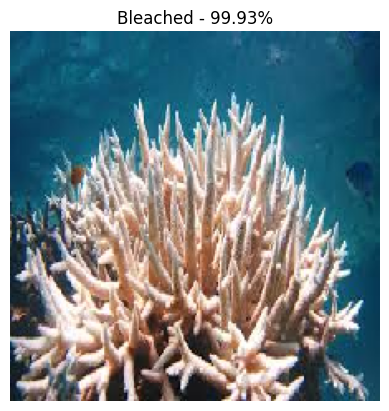

In [76]:
predict_image(r"C:\Users\TravelMate\Desktop\test12.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step


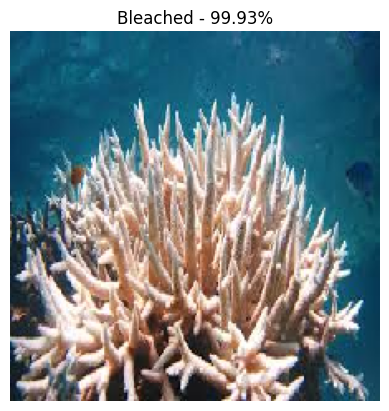

In [77]:
predict_image(r"C:\Users\TravelMate\Desktop\test12.jpg")